In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Restorasi citra yang mengalami salt and pepper noise

In [ ]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt

base_path = '/content/drive/My Drive/proyek_denoising/'
folder_input = os.path.join(base_path, 'gambar_noise')
folder_output = os.path.join(base_path, 'gambar_denoised')

In [ ]:
if not os.path.exists(folder_output):
    os.makedirs(folder_output)
    print(f"Folder '{folder_output}' telah dibuat.")

print("Memulai proses denoising...")
list_file = os.listdir(folder_input)

for filename in list_file:
    if filename.lower().endswith(('.png', '.jpg', '.jpeg')):

        path_input_gambar = os.path.join(folder_input, filename)
        path_output_gambar = os.path.join(folder_output, filename)

        # Baca gambar menggunakan OpenCV
        gambar_bernoise = cv2.imread(path_input_gambar)

        if gambar_bernoise is not None:
            # Terapkan Median Filter
            ukuran_kernel = 5
            gambar_bersih = cv2.medianBlur(gambar_bernoise, ukuran_kernel)

            # Simpan gambar yang sudah di-denoise ke folder output di Google Drive
            cv2.imwrite(path_output_gambar, gambar_bersih)

            print(f"-> Gambar '{filename}' telah diproses dan disimpan.")
        else:
            print(f"Gagal membaca gambar '{filename}'.")

print("\nProses denoising selesai. Hasil tersimpan di Google Drive Anda.")

Memulai proses denoising...
-> Gambar '1_JPG_jpg.rf.c47190cce3a7c06de1fc36c4a05b5533.jpg' telah diproses dan disimpan.
-> Gambar '29_jpg.rf.a40bc0a216d873f6dcfcc6cf7d1801c5.jpg' telah diproses dan disimpan.
-> Gambar '30_jpg.rf.77fbc0284aab92ae9e90199569c5ba79.jpg' telah diproses dan disimpan.
-> Gambar '26_jpg.rf.86706a47974ebf3076cc12f8c8874637.jpg' telah diproses dan disimpan.
-> Gambar '25_jpg.rf.1b1a7747b33d850dfbb6bd98a615dcb3.jpg' telah diproses dan disimpan.
-> Gambar '27_jpg.rf.1c71ac7925c8daaf84c09d80f147fdd0.jpg' telah diproses dan disimpan.
-> Gambar '24_JPG.rf.bcdf5ddd887689cba38407f579748e81.jpg' telah diproses dan disimpan.
-> Gambar '25_JPG.rf.f9e4efe036692656d568ad39a96e2292.jpg' telah diproses dan disimpan.
-> Gambar '23_JPG.rf.ce2d3cd16fef009a4bab7bef4dec172d.jpg' telah diproses dan disimpan.
-> Gambar '22_JPG_jpg.rf.c4fe92c7ab0977a78c9a51ce57475402.jpg' telah diproses dan disimpan.
-> Gambar '24_jpg.rf.1b8bdc9bf83bd39265848d8165fa1f41.jpg' telah diproses dan disimpa


Menampilkan beberapa contoh hasil:


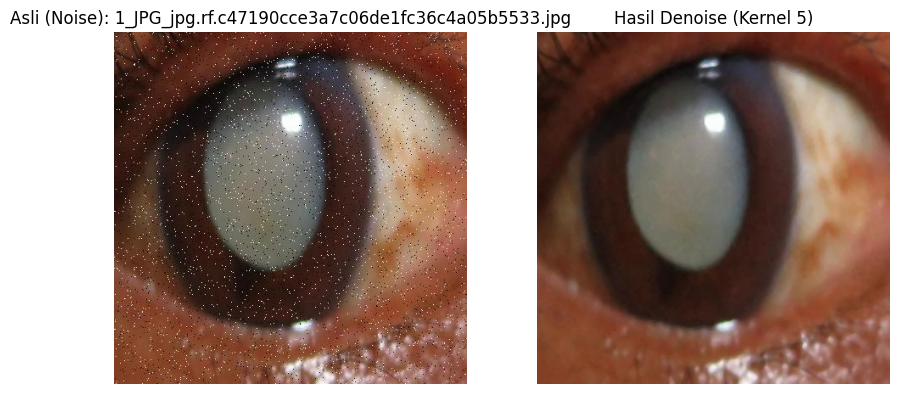

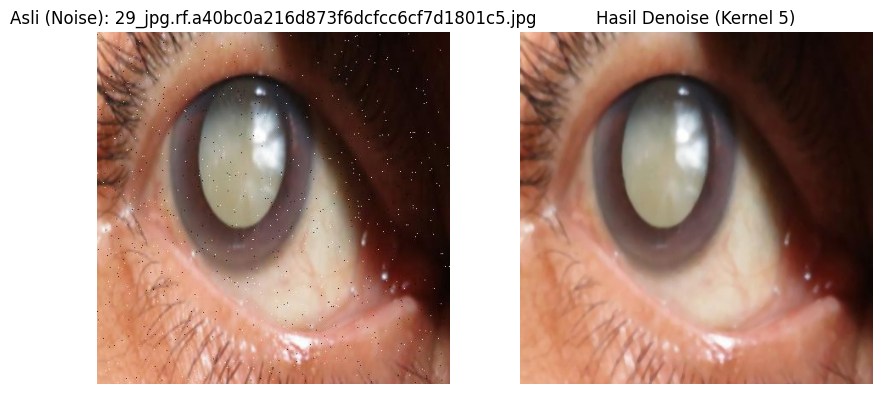

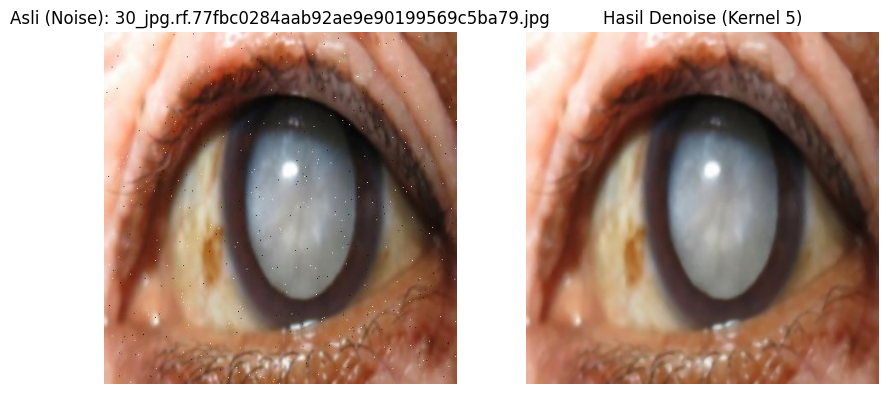

In [ ]:
print("\nMenampilkan beberapa contoh hasil:")
files_to_show = os.listdir(folder_output)[:3]

for filename_contoh in files_to_show:
    path_asli = os.path.join(folder_input, filename_contoh)
    path_bersih = os.path.join(folder_output, filename_contoh)

    img_asli = cv2.imread(path_asli)
    img_bersih = cv2.imread(path_bersih)

    img_asli_rgb = cv2.cvtColor(img_asli, cv2.COLOR_BGR2RGB)
    img_bersih_rgb = cv2.cvtColor(img_bersih, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(img_asli_rgb)
    plt.title(f'Asli (Noise): {filename_contoh}')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(img_bersih_rgb)
    plt.title(f'Hasil Denoise (Kernel {ukuran_kernel})')
    plt.axis('off')

    plt.show()